# SECCION 1

In [47]:
import pandas as pd
import numpy as np

ruta = r"customer_data (1).txt"
df_base = pd.read_csv(ruta)
df_base.head(10)

,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,multiple_lines,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,payment_method,monthly_usage_gb,customer_service_calls,churn
0,1,42,Female,24,Month-to-month,74.35,1788.45,Fiber optic,Yes,Yes,...,No,Yes,No,Yes,Yes,Yes,Electronic check,215.3,1.0,No
1,2,28,Male,6,Month-to-month,60.15,371.85,Fiber optic,Yes,No,...,No,No,No,No,No,Yes,Electronic check,134.7,0.0,Yes
2,3,57,Male,36,One year,82.55,2927.85,Fiber optic,Yes,No,...,Yes,No,Yes,Yes,No,Yes,Credit card (automatic),187.2,0.0,No
3,4,35,Female,12,Month-to-month,55.25,671.75,DSL,Yes,No,...,No,No,No,No,No,No,Bank transfer (automatic),98.4,1.0,No
4,5,61,Female,58,Two year,92.85,5293.30,Fiber optic,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Bank transfer (automatic),243.6,0.0,No
5,6,22,Male,1,Month-to-month,53.45,53.45,DSL,Yes,No,...,No,No,No,No,Yes,No,Mailed check,75.8,2.0,Yes
6,7,39,Female,3,Month-to-month,68.95,212.35,Fiber optic,Yes,No,...,No,No,No,No,No,Yes,Electronic check,165.2,3.0,Yes
7,8,45,Male,15,Month-to-month,75.65,1150.55,Fiber optic,Yes,Yes,...,Yes,No,No,Yes,Yes,Yes,Electronic check,227.9,1.0,No
8,9,63,Female,48,Two year,105.35,5060.10,Fiber optic,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Credit card (automatic),267.3,1.0,No
9,10,33,Male,9,Month-to-month,59.85,546.10,DSL,Yes,Yes,...,No,No,No,No,No,Yes,Electronic check,87.6,4.0,Yes


## limpiar y valores atipicos

In [48]:
df_limpio = df_base.copy()

# eliminar columnas y filas con valores nulos
df_limpio.dropna(axis=0, how='all', inplace=True)
df_limpio.dropna(axis=1, how='all', inplace=True)

# eliminar 
df_limpio.dropna()
df_limpio.dropna(axis=0, how='any', inplace=True)
df_limpio.drop(columns=['customer_id'], inplace=True)

In [49]:
columnas_numericas = df_limpio.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = df_limpio.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

In [50]:
q1 = df_limpio[columnas_numericas].quantile(0.25)
q3 = df_limpio[columnas_numericas].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

cantidad_atipicos = ((df_limpio[columnas_numericas] < limite_inferior) | (df_limpio[columnas_numericas] > limite_superior)).sum()
atipicos = ((df_limpio[columnas_numericas] < limite_inferior) | (df_limpio[columnas_numericas] > limite_superior))

print(cantidad_atipicos[cantidad_atipicos > 0])

total_charges    5
dtype: int64


In [51]:
df_limpio = df_limpio[~atipicos.any(axis=1)]

## Normalizar variables numéricas

In [52]:
print(df_limpio[columnas_numericas].describe())

              age  tenure_months  monthly_charges  total_charges  \
count  138.000000     138.000000       138.000000     138.000000   
mean    43.333333      24.065217        77.296377    2157.273188   
std     13.139528      19.735183        16.181972    2016.710971   
min     22.000000       1.000000        49.850000      49.850000   
25%     32.000000       7.000000        61.175000     436.325000   
50%     42.500000      19.500000        81.650000    1596.475000   
75%     53.750000      36.000000        90.650000    3263.625000   
max     75.000000      70.000000       105.350000    7336.550000   

       monthly_usage_gb  customer_service_calls  
count        138.000000              138.000000  
mean         177.003623                1.101449  
std           56.417798                1.384428  
min           68.300000                0.000000  
25%          144.625000                0.000000  
50%          195.550000                1.000000  
75%          223.275000              

In [53]:
# total_charges tiene alta desviacion, normalizarla para que tenga una distribucion mas uniforme

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_limpio["total_charges"] = scaler.fit_transform(df_limpio[["total_charges"]])

## Codificar variables categóricas

In [54]:
print(df_limpio[columnas_categoricas].describe())

        gender   contract_type internet_service phone_service multiple_lines  \
count      138             138              138           138            138   
unique       2               3                2             2              3   
top     Female  Month-to-month      Fiber optic           Yes            Yes   
freq        69              66              109           121             66   

       online_security online_backup device_protection tech_support  \
count              138           138               138          138   
unique               2             2                 2            2   
top                Yes           Yes                No           No   
freq                73            70                78           80   

       streaming_tv streaming_movies paperless_billing    payment_method churn  
count           138              138               138               138   138  
unique            2                2                 2                 4     2  


In [55]:
df_codificado = pd.get_dummies(df_limpio, columns=columnas_categoricas, drop_first=True)
df_codificado.head(10)

,age,tenure_months,monthly_charges,total_charges,monthly_usage_gb,customer_service_calls,gender_Male,contract_type_One year,contract_type_Two year,internet_service_Fiber optic,...,online_backup_Yes,device_protection_Yes,tech_support_Yes,streaming_tv_Yes,streaming_movies_Yes,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,churn_Yes
0,42,24,74.35,-0.183550,215.3,1.0,False,False,False,True,...,False,True,False,True,True,True,False,True,False,False
1,28,6,60.15,-0.888540,134.7,0.0,True,False,False,True,...,False,False,False,False,False,True,False,True,False,True
2,57,36,82.55,0.383488,187.2,0.0,True,True,False,True,...,True,False,True,True,False,True,True,False,False,False
3,35,12,55.25,-0.739290,98.4,1.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,61,58,92.85,1.560685,243.6,0.0,False,False,True,True,...,True,True,True,True,True,True,False,False,False,False
5,22,1,53.45,-1.046996,75.8,2.0,True,False,False,False,...,False,False,False,False,True,False,False,False,True,True
6,39,3,68.95,-0.967917,165.2,3.0,False,False,False,True,...,False,False,False,False,False,True,False,True,False,True
7,45,15,75.65,-0.501009,227.9,1.0,True,False,False,True,...,True,False,False,True,True,True,False,True,False,False
8,63,48,105.35,1.444630,267.3,1.0,False,False,True,True,...,True,True,True,True,True,True,True,False,False,False
9,33,9,59.85,-0.801822,87.6,4.0,True,False,False,False,...,False,False,False,False,False,True,False,True,False,True


## nuevas características

In [56]:
df_codificado["chargesVsTenure"] = df_codificado["total_charges"] / df_codificado["tenure_months"]
df_codificado["ageVsUsage"] = df_codificado["age"] / df_codificado["monthly_usage_gb"]
df_codificado["ServicecallsVsCharges"] = df_codificado["customer_service_calls"] / df_codificado["total_charges"]

## visualizacion

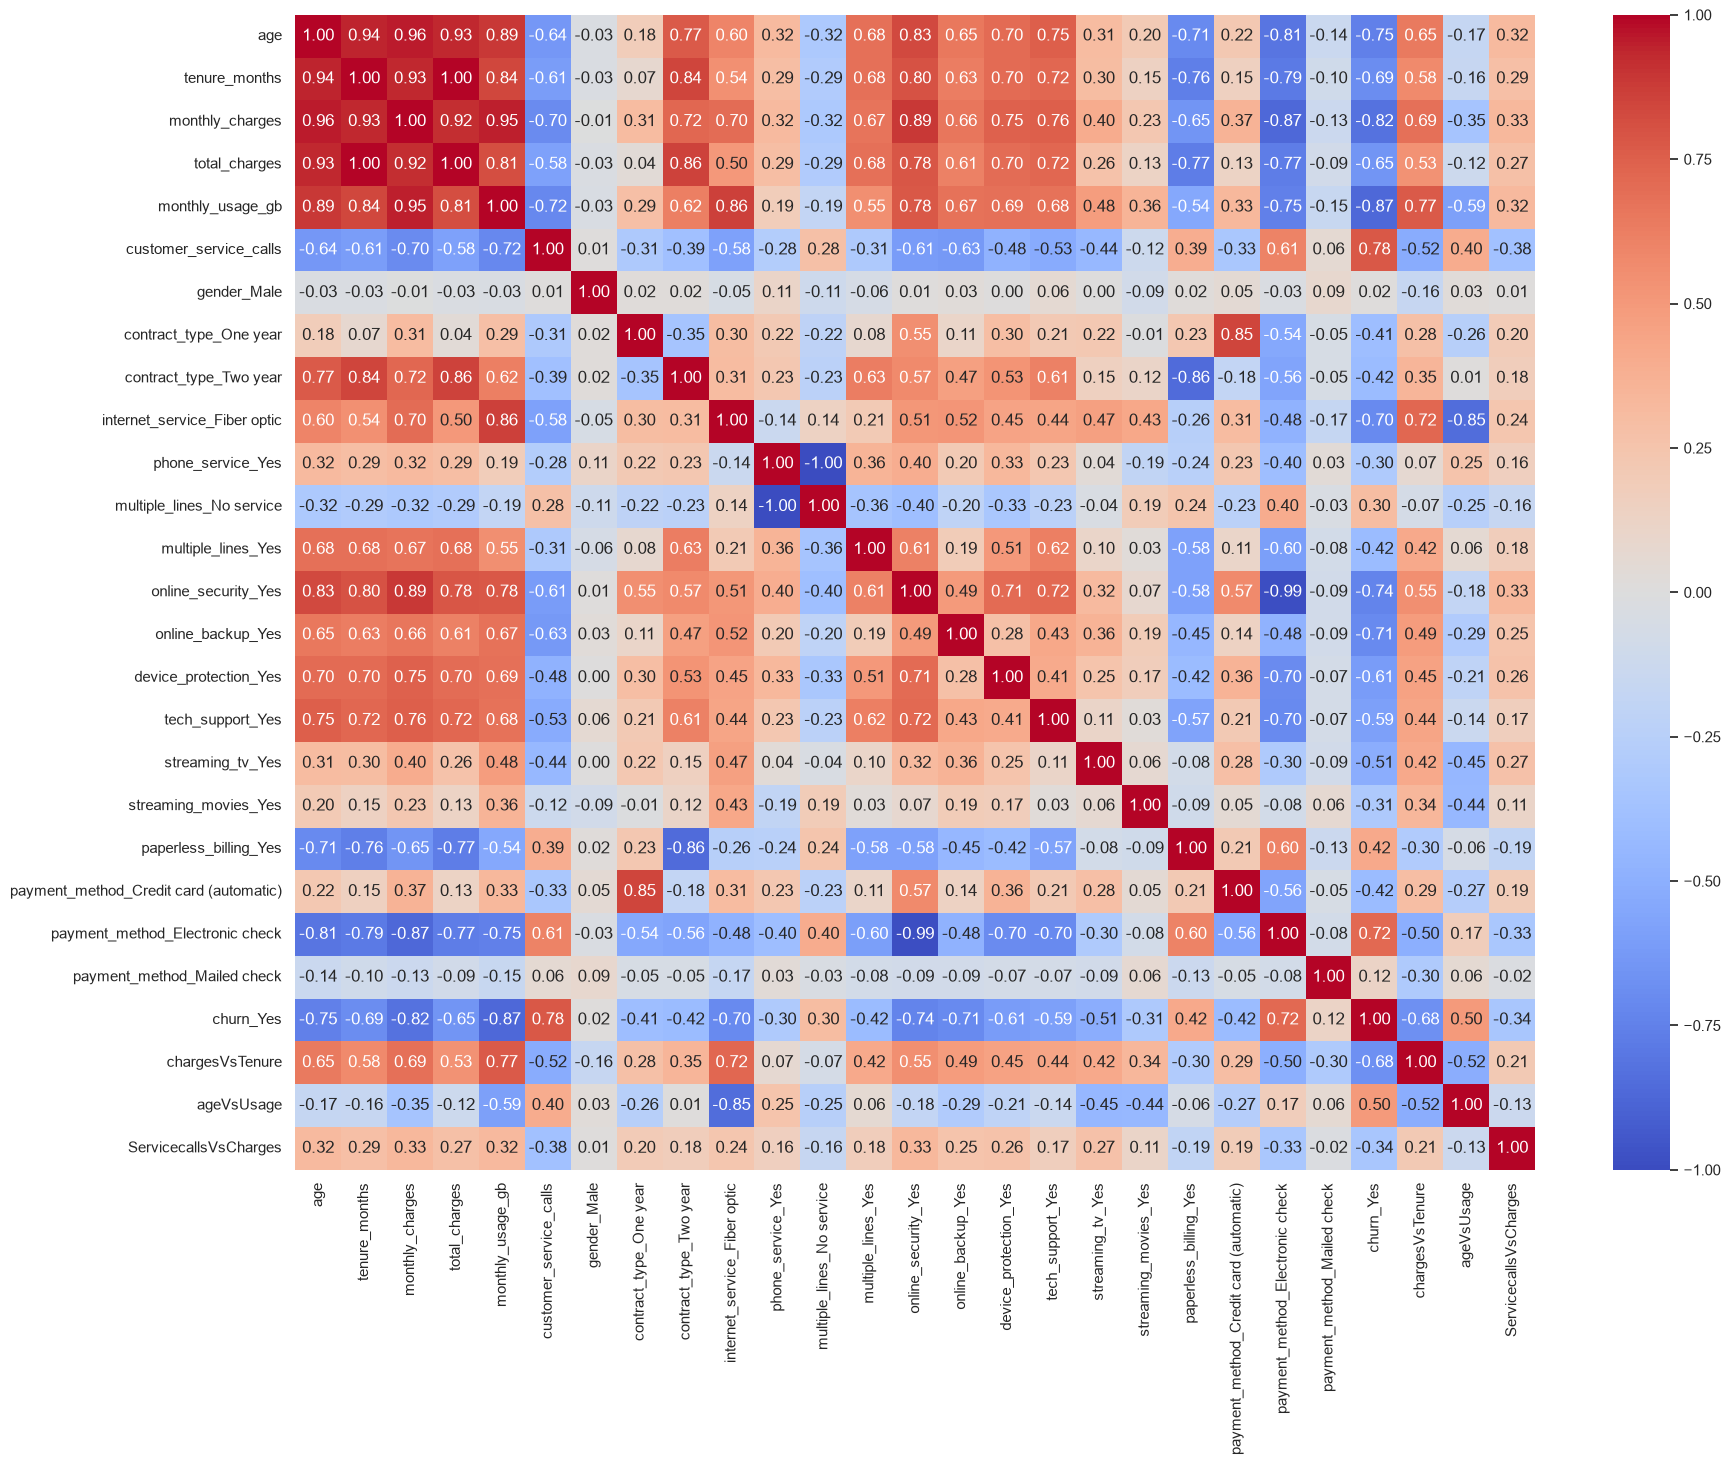

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

matriz_correlacion = df_codificado.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

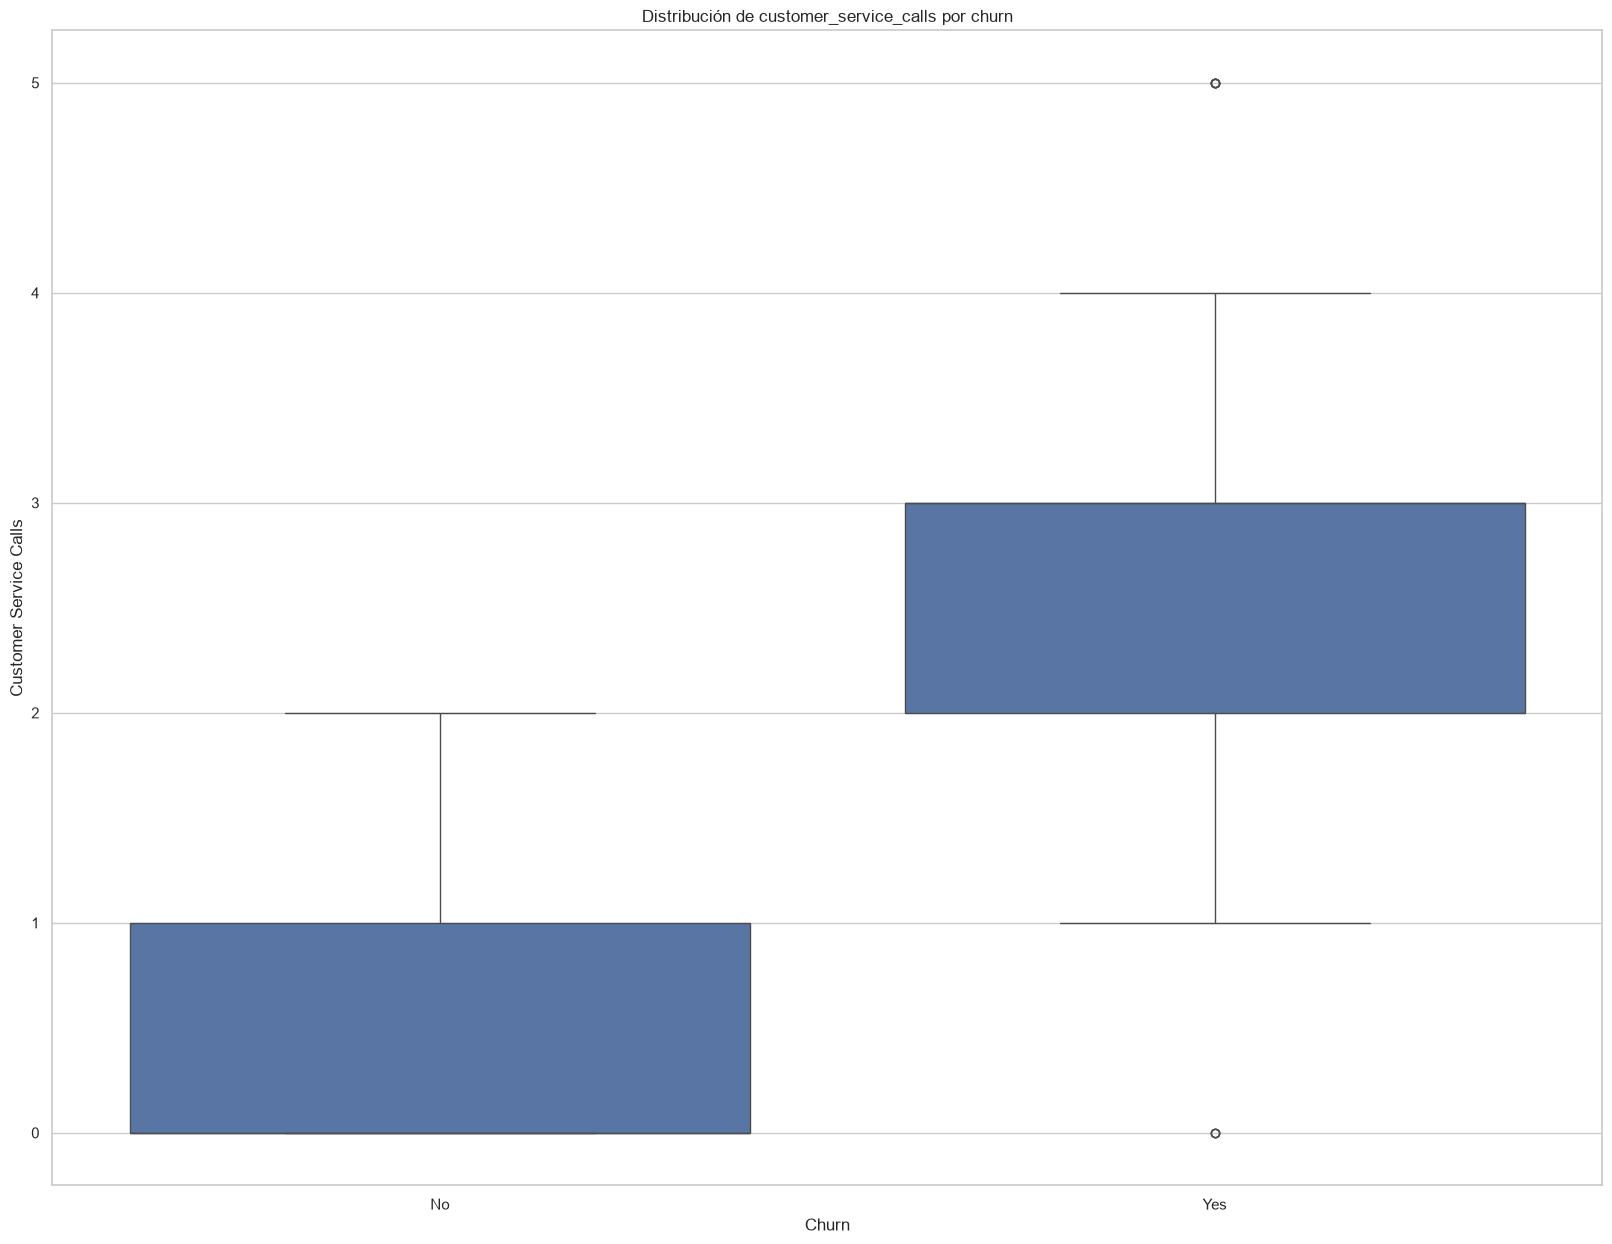

In [58]:
plt.figure(figsize=(20, 15))
sns.boxplot(data=df_base, x='churn', y='customer_service_calls')

plt.title('Distribución de customer_service_calls por churn')
plt.xlabel('Churn')
plt.ylabel('Customer Service Calls')
plt.show()

# SECCION 2

In [59]:
df_codificado.columns

Index(['age', 'tenure_months', 'monthly_charges', 'total_charges',
       'monthly_usage_gb', 'customer_service_calls', 'gender_Male',
       'contract_type_One year', 'contract_type_Two year',
       'internet_service_Fiber optic', 'phone_service_Yes',
       'multiple_lines_No service', 'multiple_lines_Yes',
       'online_security_Yes', 'online_backup_Yes', 'device_protection_Yes',
       'tech_support_Yes', 'streaming_tv_Yes', 'streaming_movies_Yes',
       'paperless_billing_Yes', 'payment_method_Credit card (automatic)',
       'payment_method_Electronic check', 'payment_method_Mailed check',
       'churn_Yes', 'chargesVsTenure', 'ageVsUsage', 'ServicecallsVsCharges'],
      dtype='str')

In [60]:
df_codificado.shape

(138, 27)

In [61]:
# conjuntos
from sklearn.model_selection import train_test_split

X = df_codificado.drop('churn_Yes', axis=1)
y = df_codificado['churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
# modelos
# import sklearn as sk

# modelo_logistico = sk.linear_model.LogisticRegression(max_iter=1000, )
# modelo_rf = sk.ensemble.RandomForestClassifier()

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_rf = RandomForestClassifier(random_state=42)

modelo_logistico.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)

predicciones_logistico = modelo_logistico.predict(X_test)
predicciones_rf = modelo_rf.predict(X_test)

# metricas 
print(classification_report(y_test, predicciones_logistico))
print(classification_report(y_test, predicciones_rf))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00        20
        True       1.00      1.00      1.00         8

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28

              precision    recall  f1-score   support

       False       1.00      1.00      1.00        20
        True       1.00      1.00      1.00         8

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28



NOTA, con la primera iteracion parece que ambos modelo obtuvieron perfectos resultados en predicciones. Puede que sea acausa de la data dummy.
En todo caso, procedo con el desarrollo de como seria la optimizacion de hiperparametros

In [65]:
# Hiperparametros
from sklearn.model_selection import RandomizedSearchCV

parametros_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

rf_modelo = RandomForestClassifier(random_state=42)
busqueda_aleatoria = RandomizedSearchCV(estimator=rf_modelo, param_distributions=parametros_rf, n_iter=10, cv=5, scoring="recall", verbose=2, random_state=42, n_jobs=-1)
busqueda_aleatoria.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function wh

In [67]:
modelo_mejorado = busqueda_aleatoria.best_estimator_
predicciones_mejoradas = modelo_mejorado.predict(X_test)

print(classification_report(y_test, predicciones_mejoradas))

              precision    recall  f1-score   support

       False       1.00      0.95      0.97        20
        True       0.89      1.00      0.94         8

    accuracy                           0.96        28
   macro avg       0.94      0.97      0.96        28
weighted avg       0.97      0.96      0.96        28



## xplicabilidad del modelo

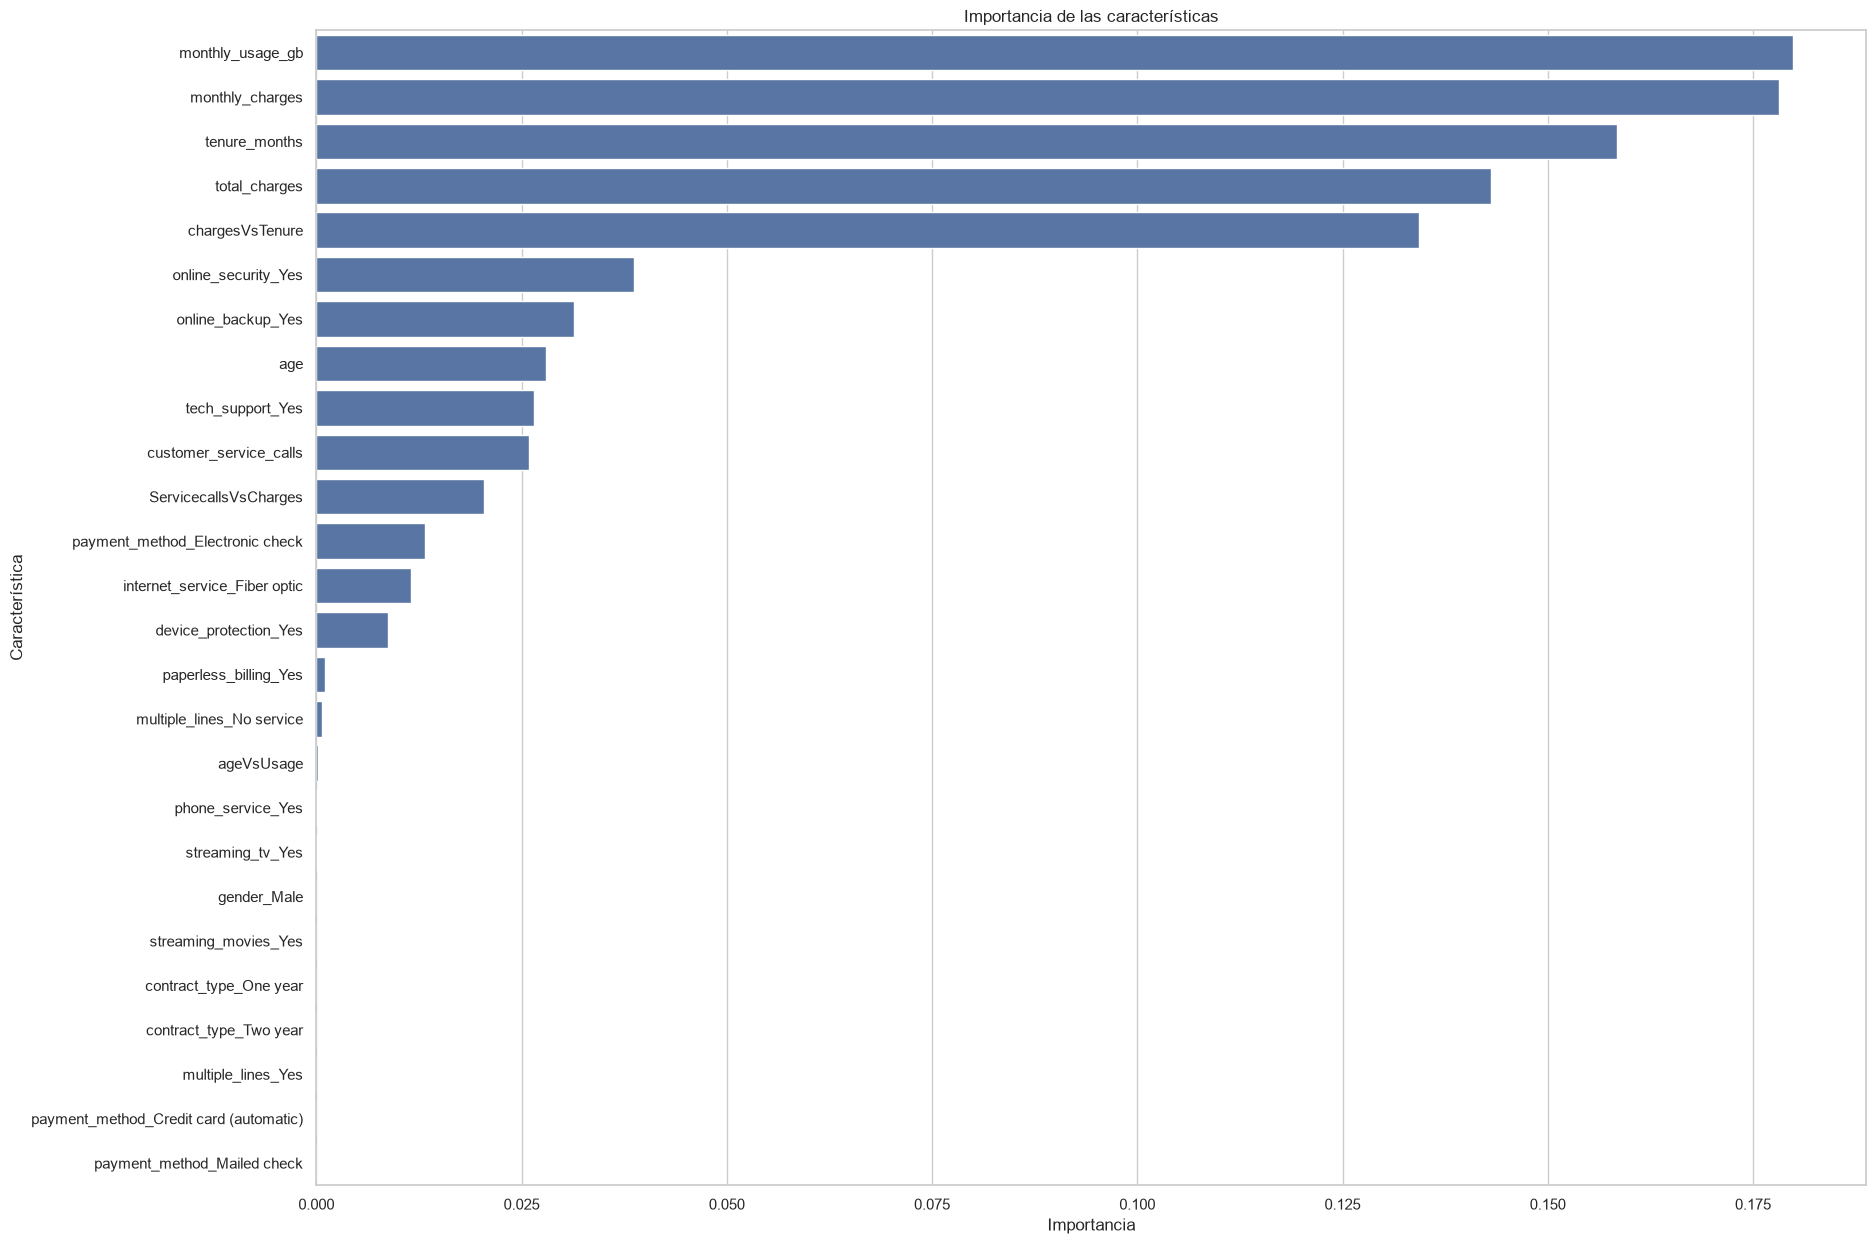

In [71]:
importancias = modelo_mejorado.feature_importances_

df_importancias = pd.DataFrame({"Característica": X.columns, "Importancia": importancias})
df_importancias = df_importancias.sort_values(by="Importancia", ascending=False)


plt.figure(figsize=(20, 15))
sns.barplot(x="Importancia", y="Característica", data=df_importancias)
plt.title("Importancia de las características")
plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.show()

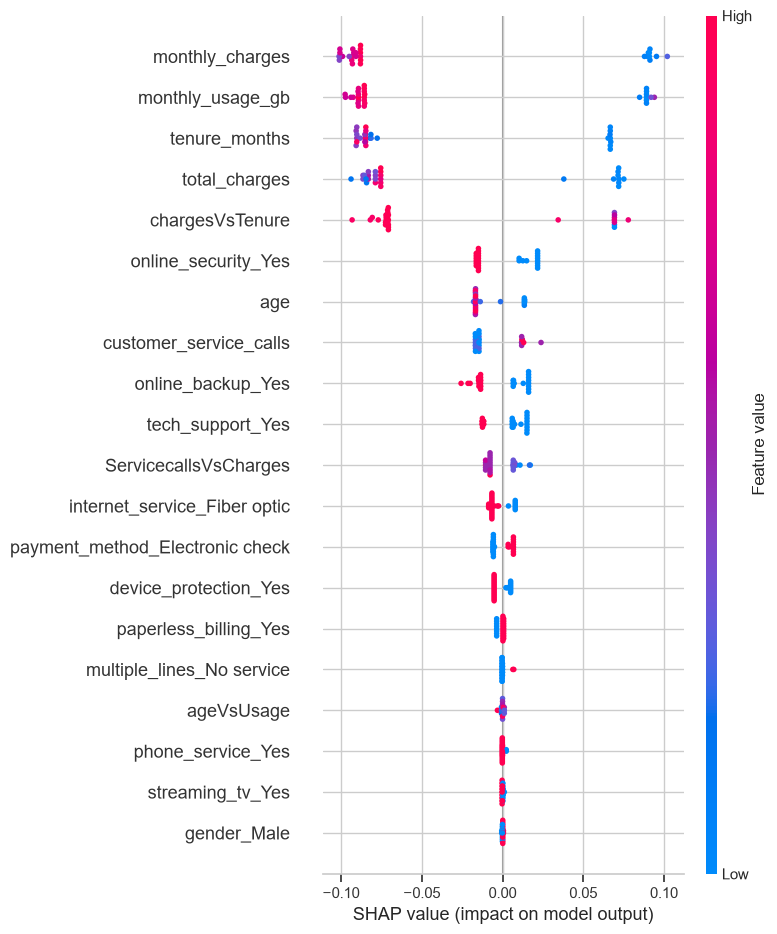

In [76]:
import shap

explainer = shap.TreeExplainer(modelo_mejorado)
valores_shap = explainer.shap_values(X_test)
abandonos = valores_shap[:,:,1]
shap.summary_plot(abandonos, X_test)

Explicacion: en la grafica anterior se pueden ver los parametros mas relevantes para el modelo de forma descendente.
Ademas se determina si son mas o menos relevantes con el color, entre mas rojo mas relevancia
Por otro lado los valores mas a la izquierda son datos que 'ayudan' a que un cliente se vaya y entre mas a la derecha a que se queden

De los primeros  parametros se puede obserar que hay una distincion muy marcada y con mucha influencia, esto explicaria por que los modelo fncionaron tan bien en una primera iteracion

# SECCION 3

In [77]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

In [92]:
import tensorflow as tf

y_codificado = tf.keras.utils.to_categorical(y, num_classes=10)

X_train, X_test, y_train, y_test = train_test_split(X, y_codificado, test_size=0.2, random_state=42)

modelo = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
modelo.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

c:\Users\npolindaral\.conda\envs\env_base\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8369 - loss: 1.7677 - val_accuracy: 0.8937 - val_loss: 0.4272
Epoch 2/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9166 - loss: 0.3271 - val_accuracy: 0.9187 - val_loss: 0.3162
Epoch 3/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9390 - loss: 0.2254 - val_accuracy: 0.9414 - val_loss: 0.2163
Epoch 4/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9512 - loss: 0.1770 - val_accuracy: 0.9437 - val_loss: 0.2210
Epoch 5/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9568 - loss: 0.1571 - val_accuracy: 0.9535 - val_loss: 0.1814
Epoch 6/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9633 - loss: 0.1279 - val_accuracy: 0.9587 - val_loss: 0.1724
Epoch 7/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9668 - loss: 0.1202 - val_accuracy: 0.9579 - val_loss: 0.1669
Epoch 8/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9722 - loss: 0.1034 - 

In [93]:
loss, accuracy = modelo.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9651 - loss: 0.1673
Loss: 0.1673479676246643, Accuracy: 0.965071439743042


In [94]:
predicciones = modelo.predict(X_test)

clases = np.argmax(predicciones, axis=1)
clases_test = np.argmax(y_test, axis=1) 

print(classification_report(clases_test, clases))

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1343
           1       0.99      0.99      0.99      1600
           2       0.96      0.97      0.96      1380
           3       0.98      0.95      0.96      1433
           4       0.96      0.96      0.96      1295
           5       0.97      0.96      0.96      1273
           6       0.97      0.98      0.97      1396
           7       0.98      0.96      0.97      1503
           8       0.95      0.96      0.95      1357
           9       0.91      0.96      0.94      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.96      0.96     14000
weighted avg       0.97      0.97      0.97     14000



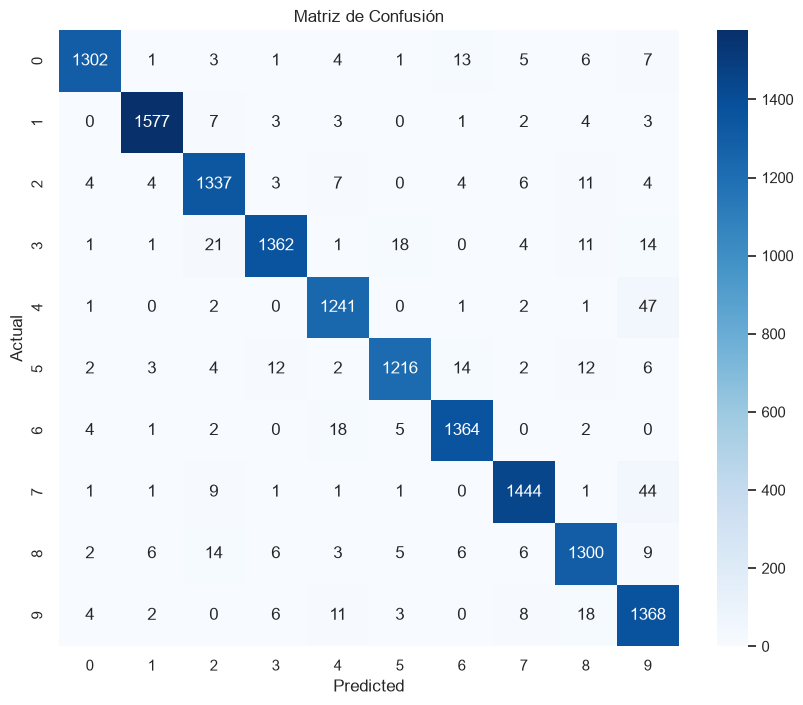

In [95]:
matrix = confusion_matrix(clases_test, clases)

plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title('Matriz de Confusión')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# SECCION 4

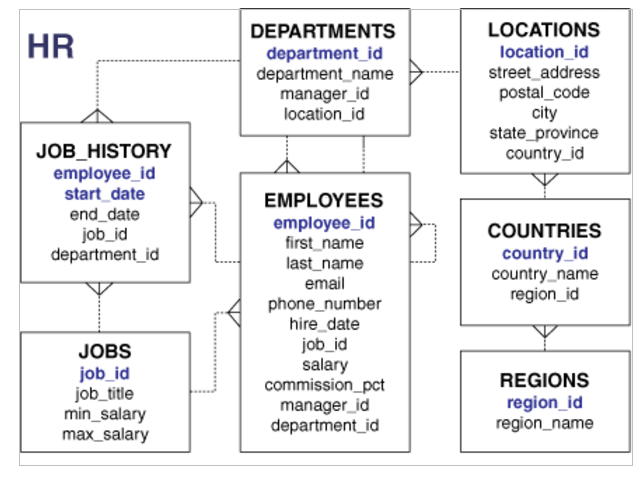

        a. Consulta a los empleados cuyo salario sea superior a los del promedio de su departamento.
        b. Consulta el salario promedio de los manager por regiones.
        c. Lista los empleados y sus manager y ordenar por nombre de departamento.

In [ ]:
# a. Consulta a los empleados cuyo salario sea superior a los del promedio de su departamento.

# SELECT employee_id
# FROM EMPLOYEES
# WHERE salary > (SELECT AVG(salary) FROM EMPLOYEES WHERE department_id = EMPLOYEES.department_id)  

In [ ]:
# b. Consulta el salario promedio de los manager por regiones.

# SELECT region_id, AVG(salary) AS avg_salary
# FROM EMPLOYEES
# JOIN DEPARTMENTS ON EMPLOYEES.department_id = DEPARTMENTS.department_id
# JOIN LOCATIONS ON LOCATIONS.location_id = LOCATIONS.location_id
# JOIN COUNTRIES ON COUNTRIES.country_id = COUNTRIES.country_id
# JOIN REGIONS ON DEPARTMENTS.region_id = REGIONS.region_id
# WHERE employee_id IN (SELECT DISTINCT manager_id FROM EMPLOYEES)
# GROUP BY region_id

In [ ]:
# c. Lista los empleados y sus manager y ordenar por nombre de departamento.

# SELECT e.first_name, m.first_name, e.department_id
# FROM EMPLOYEES e
# LEFT JOIN EMPLOYEES m ON e.manager_id = m.employee_id
# LEFT JOIN DEPARTMENTS d ON e.department_id = d.department_id
# ORDER BY d.department_name

# SECCION 5

1. Describe la arquitectura que utilizarías (diagrama opcional)
   - Peticion del cliente: Una aplicacion frontend envia un mensaje a un endpoint publico
   - Capa de entrada y enrutamiento: Un enlace via API recibe la peticion y enruta el trafico
   - Capa de computo: Un cluster de contenedores cargan el modelo y lo ejecutan.
   - Almacenamiento de artefactos: contenedores que cargan los pesos del modelo
   - Capa de datos: Si el modelo necesita enriquecer los datos de entrada antes de predecir, consulta una base de datos para features

2. Explica qué servicios en la nube utilizarías
   - API y Enrutamiento: Cloud Enpoints
   - Computacion ML: Vertex AI Endpoints
   - Almacenamiento del modelo: Cloud storage
   - Registro de modelo: Vertex IA Model
   - Feature store: Cloud bigtable

3. Detalla cómo manejarías: 
   - Escalabilidad: escalado horizontal
        - Auro-Sacaling: añadir mas instancias, como nodos o contenedores, cuando el uso de CPU supere algun umbral
        - Inferencia serverless: Cuando hallan cargas de trabajo con uso intermitente
   - Monitoreo del rendimiento: metricas del sistema y metricas de ML
        - Metricas de infraestructura: herramientas para rastrear latencia de respuesta, tasa de errores y uso de memoria
        - Drift de data: Se intercepta un porcentaje del trafico de entrada y salida para compara la distribucion de los datos con la distribucion de os datos con el que el modelo gue entrenado para detectar degradaciones
   - Actualización del modelo: estrategias de CI/CD
        -  Despliegue paralelo: Se levanta el nuevo modelo en paralelo con el antiguo, si pasa los test, todo el trafico se manda al nuevo
        -  Despliegue en privado: el modelo nuevo recive una copia del trafico en produccion y genera predicciones, pero se quedan en privado para evaluar el rendimiento 
   - Seguridad de los datos:
        - Uso de VPC
        - Cifrados
        - Gestion de accesos
        - Contenedores con principio de minimo privilegio 

# SECCION 6

Sección 6: IA Generativa (15 minutos)
Utiliza un modelo de IA generativa para:
    1. Crear un prompt efectivo que genere un análisis de sentimiento para reseñas de clientes
    2. Explica brevemente cómo se  integraría esta solución en un pipeline de datos existente

In [ ]:
promt = """
Eres un analista experto en experiencia del cliente. Tu tarea es analizar las reseñas de clientes y retornar un analisis de sentimiento

Para cada reseña, determina:
1. Clasifica el sentimiento estrictamente como "Positivo", "Negativo" o "Neutral".
2. Identidica la emocion principal expresada en la reseña (por ejemplo: alegría, tristeza, enojo, sorpresa, miedo, etc.).
3. Extrae una lista de palabras clave que capturen los temas o aspectos más importantes mencionados en la reseña.

Retrona la respuesta UNICAMENTE en formato plano separado con |

Ejemplo:
"sentimiento: Positivo | emocion: alegría | palabras clave: servicio, rápido, amable"

Reseñas a analizar:
{insertar reseñas aquí}
"""

INTEGRACION:
- Ingesta de datos/extraccion: procesos ETL por lotes
- Procesamiento mediante API: Script de python ejecutado como tarea programada que inyecta los textos, el prommt y llama las API del modelo 
- Almacenaminto: Los datos se insertan en tablas estructuradas
- Visualizacion: herramientas de reporterra para mostrar la evoucion e insights 